## Методические указания по выполнению лабораторной работы №4

**Тема: Сегментация объектов с использованием Mask R-CNN**

**Цель работы:** Познакомиться с архитектурой Mask R-CNN и научиться выполнять сегментацию объектов на изображениях.

**Задачи:**

- Изучить теоретические основы instance segmentation.
- Ознакомиться с архитектурой Mask R-CNN.
- Провести инференс предобученной модели на выбранных изображениях.
- Визуализировать результаты: bounding boxes, маски объектов.
- Рассчитать метрики оценки качества масок.
- Проанализировать ошибки сегментации.
- Провести исследование зависимости качества от параметров confidence score и mask threshold.

### 1. Теоретическая часть

В данной лабораторной работе мы познакомимся с задачей детекции на примере архитектуры [Mask R-CNN](https://arxiv.org/pdf/1703.06870), обученной на наборе данных [COCO](https://cocodataset.org/#home), а также с новой задачей компьютерного зрения - сегментацией.

**Перед тем, как приступать к выполнению практической части, ознакомьтесь с первоисточниками используемых компонентов, а также документацией по [ссылке](https://pytorch.org/vision/main/models/mask_rcnn.html), включающей подробности работы с моделью и новым форматом данных, сэмплы кода.**

#### 1.1 Instance Segmentation и архитектура Mask R-CNN

Instance segmentation — это задача, в которой необходимо не только обнаружить объект и его класс, но и сегментировать его границы на уровне пикселей. Это усложнённая версия задачи детекции, так как bounding box не всегда точно соответствует форме объекта.

В отличие от semantic segmentation, где модель выдает одну маску на класс, в instance segmentation выделяется каждый объект независимо, даже если они относятся к одному классу.

Mask R-CNN — это расширение Faster R-CNN, дополненное ещё одним выходом: бинарной маской для каждого обнаруженного объекта.

Архитектура Mask R-CNN включает:

1. Backbone (например, ResNet-50) — извлекает карты признаков из изображения.
2. Region Proposal Network (RPN) — предлагает кандидаты на объекты.
3. ROI Align / ROI Pooling — извлекает фиксированные области из фичей.
4. Bounding Box Head — классифицирует объект и уточняет координаты.
5. Mask Head — предсказывает маску для каждого класса, соответствующую bounding box.


#### 1.2 Формат данных для задачи детекции

При запуске инференса модель возвращает словарь с результатами: координаты bounding boxes, классы объектов, confidence score и маски объектов (представлены как float значения от 0 до 1).

В рамках выполнения работы в зависимости от варианта вам предстоит познакомиться с другими форматами файлов и их содержимым.

### Варианты

Выполните задание в соответствии со своим вариантом по списку с использованием предобученной модели.

**Вариант 1  - Pascal VOC 2007. Сравнить предсказания модели с реальной разметкой и провести количественную оценку:**

- Выполнить инференс модели на 20 изображениях;
- Визуализировать bounding boxes и маски;
- Проанализировать качество предсказаний;
- Описать, какие классы модель распознала, какие пропустила.

**Вариант 2 — COCO 2017. Сравнить предсказания модели с реальной разметкой и провести количественную оценку:**

- Выполнить инференс на 20 изображениях;
- Визуализировать предсказания;
- Сравнить полученные маски с ground truth;
- Рассчитать IoU, Pixel Accuracy или Precision/Recall;

**Вариант 3 — Cityscapes. Проверить, как модель работает на новых изображениях, визуализировать предсказания и сравнить с известными аннотациями:**

- Выполнить инференс на 20 изображениях;
- Визуализировать предсказания;
- Сравнить полученные маски с ground truth;
- Рассчитать IoU, Pixel Accuracy или Precision/Recall;


### 2. Практическая часть

#### 2.1 Подготовка окружения

Установите зависимости и библиотеки:

Я 25, так что 1 вариант, но [VOC недоступен](https://github.com/pytorch/vision/issues/9271)

In [1]:
# импорт пакетов
import torch
from torch import nn
import torchvision.transforms as transforms
from torchvision import models, datasets
import cv2
from skimage.measure import regionprops
from scipy.optimize import linear_sum_assignment
from torch.utils.data import Dataset, DataLoader
from PIL import Image
from tqdm import tqdm

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import glob
import os
import zipfile
import xml.etree.ElementTree as ET
from pathlib import Path

#### 2.2 Подготовка модели

Загрузите предобученную модель, определите устройство, переведите модель в режим инференса:

In [2]:
# импорт модели
model = models.detection.maskrcnn_resnet50_fpn_v2(pretrained=True)

# Устройство
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f"Используемое устройство: {device}")

model.to(device)
model.eval()

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=MaskRCNN_ResNet50_FPN_V2_Weights.COCO_V1`. You can also use `weights=MaskRCNN_ResNet50_FPN_V2_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Используемое устройство: cuda


MaskRCNN(
  (transform): GeneralizedRCNNTransform(
      Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
      Resize(min_size=(800,), max_size=1333, mode='bilinear')
  )
  (backbone): BackboneWithFPN(
    (body): IntermediateLayerGetter(
      (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
      (layer1): Sequential(
        (0): Bottleneck(
          (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
          (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
          (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
         

#### 2.3 Загрузка и предобработка изображений


Затем импортируйте датасет из соответствующих пакетов PyTorch и определите метод трансформации данных для подачи в модель:

In [3]:
# метод трансформации
HEIGHT, WIDTH = (512, 512)
transform = transforms.Compose([
    transforms.Resize((512, 512)),
    transforms.ToTensor()
])

# загрузка датасета
# тут мы сосём бибу
# voc_dataset = datasets.VOCSegmentation(root='./data/', year='2007', image_set='test', download=True, transform=transform)

# качаем с кегли
import kagglehub

path = kagglehub.dataset_download("zaraks/pascal-voc-2007")
path+="/voctest_06-nov-2007/VOCdevkit/VOC2007/"
path

Using Colab cache for faster access to the 'pascal-voc-2007' dataset.


'/kaggle/input/pascal-voc-2007/voctest_06-nov-2007/VOCdevkit/VOC2007/'

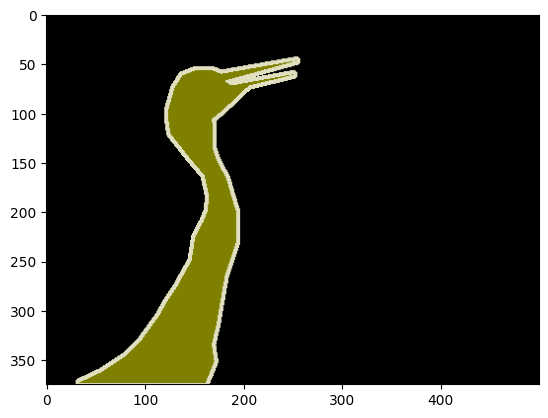

In [4]:
img = cv2.imread(path+"SegmentationClass/000068.png")
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
plt.imshow(img)

#### 2.4 Предсказания и извлечение масок

Если вы работаете с Pascal VOC, вам потребуется прочитать файлы, содержащие разметку. Если вы работаете с COCO или Cityscapes, аннотации читаются через готовые методы COCO API:

In [5]:
# методы извлечения меток и визуализации
class VOCDataset(Dataset):
    def __init__(self, path: str, transforms) -> None:
        self.images = path+"JPEGImages/"
        self.masks = path+"SegmentationClass/"

        annotations_path = path+"Annotations/"
        files = list(glob.glob(annotations_path+"*.xml"))
        self.files = list(self.validate_pathes(files))
        self.transforms = transforms

    def __len__(self) -> int:
        return len(self.files)

    def __getitem__(self, idx: int) -> tuple:
        # parse annotations
        annotation = self.files[idx]
        img, obj_info = self.parse_xml(annotation)

        # get mask and bboxes
        mask = cv2.imread(self.masks+Path(annotation).stem+".png", cv2.IMREAD_GRAYSCALE)

        # transform
        img = self.transforms(Image.fromarray(img))
        mask = self.transforms(Image.fromarray(mask))

        return img, mask, obj_info

    def parse_xml(self, annotation_path: str) -> tuple[str, dict]:
        tree = ET.parse(annotation_path)
        root = tree.getroot()
        img_name = root.find('filename').text
        objects = []

        img = cv2.imread(self.images+img_name, cv2.IMREAD_COLOR)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

        orig_h, orig_w = img.shape[:2]
        scale_x = WIDTH / orig_w
        scale_y = HEIGHT / orig_h

        for obj in root.findall('object'):
            obj_data = {
                'name': obj.find('name').text,
                'bndbox': {
                    'xmin': int(int(obj.find('bndbox/xmin').text)*scale_x),
                    'ymin': int(int(obj.find('bndbox/ymin').text)*scale_y),
                    'xmax': int(int(obj.find('bndbox/xmax').text)*scale_x),
                    'ymax': int(int(obj.find('bndbox/ymax').text)*scale_y),
                }
            }
            objects.append(obj_data)

        return img, objects

    def validate_pathes(self, pathes: list[str]):
        for path in pathes:
            stemed = Path(path).stem
            if Path(self.images+stemed+".jpg").exists() and Path(self.masks+stemed+".png").exists():
                yield path

ds = VOCDataset(path, transform)
len(ds)

210

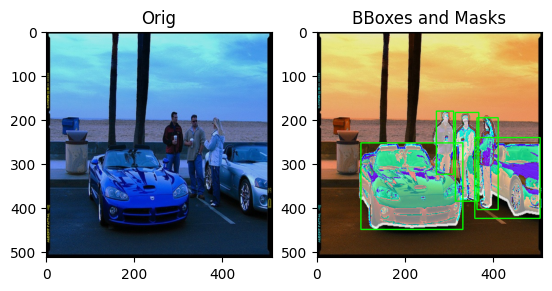

In [6]:
def plot_pair(img, mask, objects):
    _, ax = plt.subplots(1, 2)
    ax[0].imshow(ds[0][0].permute(1,2,0))
    ax[0].set_title("Orig")

    masked = ds[0][0] + ds[0][1]
    masked = (masked.permute(1, 2, 0).numpy() * 255).astype(np.uint8)
    masked = cv2.cvtColor(masked, cv2.COLOR_RGB2BGR)
    for obj in objects:
        xmin = obj["bndbox"]["xmin"]
        ymin = obj["bndbox"]["ymin"]
        xmax = obj["bndbox"]["xmax"]
        ymax = obj["bndbox"]["ymax"]

        cv2.rectangle(
            masked,
            (xmin, ymin),
            (xmax, ymax),
            (0, 255, 0),
            2
        )
    ax[1].imshow(masked)
    ax[1].set_title("BBoxes and Masks")
    plt.show()

plot_pair(*ds[0])

#### 2.5 Оценка модели и визуализация результатов

Визуализируйте bounding box, название класса, маску поверх изображения. Для каждой маски и её соответствующего ground truth (если имеется), вычислите: IoU, количество FP пикселей, количество FN пикселей:

IoU по своей сути представляет собой:

$$IoU = \frac{True Mask (TM) \cap Predicted Mask (PM)}{TM \cup PM}$$

То есть чем точнее наша маска совпадает с реальной, тем ближе IoU к 1 (макс значение). Если представить изображение в виде пикселей, то его можно перевести в TFPN нотацию - где TM и PM пересекаются, предсказание модели будет TP, где есть TM есть, но нет PM - FN, а наоборот - FP. Тогда метрику IoU можно записать как:

$$IoU = \frac{TP}{TP+FP+FN}$$

In [7]:
# инференс
def iou(preds: torch.Tensor, gt_mask: torch.Tensor, conf_threshold: float = 0.5, mask_threshold: float = 0.5, eps: float = 1e-6) -> torch.Tensor:
    conf_score_mask = (preds["scores"] >= conf_threshold)

    # masks
    pred_mask = preds["masks"][conf_score_mask].cpu()
    gt_binary = (gt_mask > 0).bool()[0]

    if pred_mask.numel() == 0:  # No detections
        pred_combined = torch.zeros_like(gt_binary)
    else:
        pred_combined = (pred_mask > mask_threshold).any(dim=0)

    # intersection = (pred_combined & gt_binary).sum()
    # union = (pred_combined | gt_binary).sum()

    # return (intersection + eps) / (union + eps)
    tp = (pred_combined & gt_binary).sum(dim=(1, 2))
    fp = (pred_combined & ~gt_binary).sum(dim=(1, 2))
    fn = (~pred_combined & gt_binary).sum(dim=(1, 2))

    iou_score = (tp + eps) / (tp + fp + fn + eps)
    prec = (tp + eps) / (tp + fp + eps)
    rec = (tp + eps) / (tp + fn + eps)

    return iou_score, fp, fn, prec, rec

def inference(model: nn.Module, ds: Dataset, device: str = "cuda", conf_threshold: float=0.5, mask_threshold: float=0.5, leave: bool = True):
    dl = DataLoader(ds, batch_size=1, pin_memory=device=="cuda", num_workers=2)
    iou_metric = fp_metric = fn_metric = prec_metric = rec_metric = 0
    with torch.inference_mode():
        for (img, masks, _) in tqdm(dl, leave=leave):
            img = img.to(device, non_blocking=device=="cuda")
            outputs = model(img)
            iou_score, fp_score, fn_score, prec_score, rec_score = iou(outputs[0], masks, conf_threshold, mask_threshold)

            iou_metric += iou_score.item()
            fp_metric += fp_score.item()
            fn_metric += fn_score.item()
            prec_metric += prec_score.item()
            rec_metric += rec_score.item()
    return list(map(lambda x: x / len(ds), (iou_metric, fp_metric, fn_metric, prec_metric, rec_metric)))

inference(model, ds, device=device)

100%|██████████| 210/210 [00:31<00:00,  6.66it/s]


[0.7585431542780198,
 11821.390476190476,
 10118.2,
 0.8917228957194657,
 0.8404740627323357]

#### 2.6 Исследование параметров маски и confidence

Проведите серию экспериментов: протестируйте разные значения mask_threshold (0.3, 0.5, 0.7), протестируйте разные значения confidence_threshold, найдите оптимальное значение, при котором достигается лучший баланс между точностью и полнотой:


Тут только добавить формулы:
$$Precisoin = \frac{TP}{TP+FP}$$
$$Recall = \frac{TP}{TP+FN}$$

В душе не чаю, для чего нужны два порога. Представим, что мы сначала отбираем порог по scores, а потом ещё раз, но уже по маске.

Плюс нас не просили, но раз графика 3, то ещё и IoU посчитаем

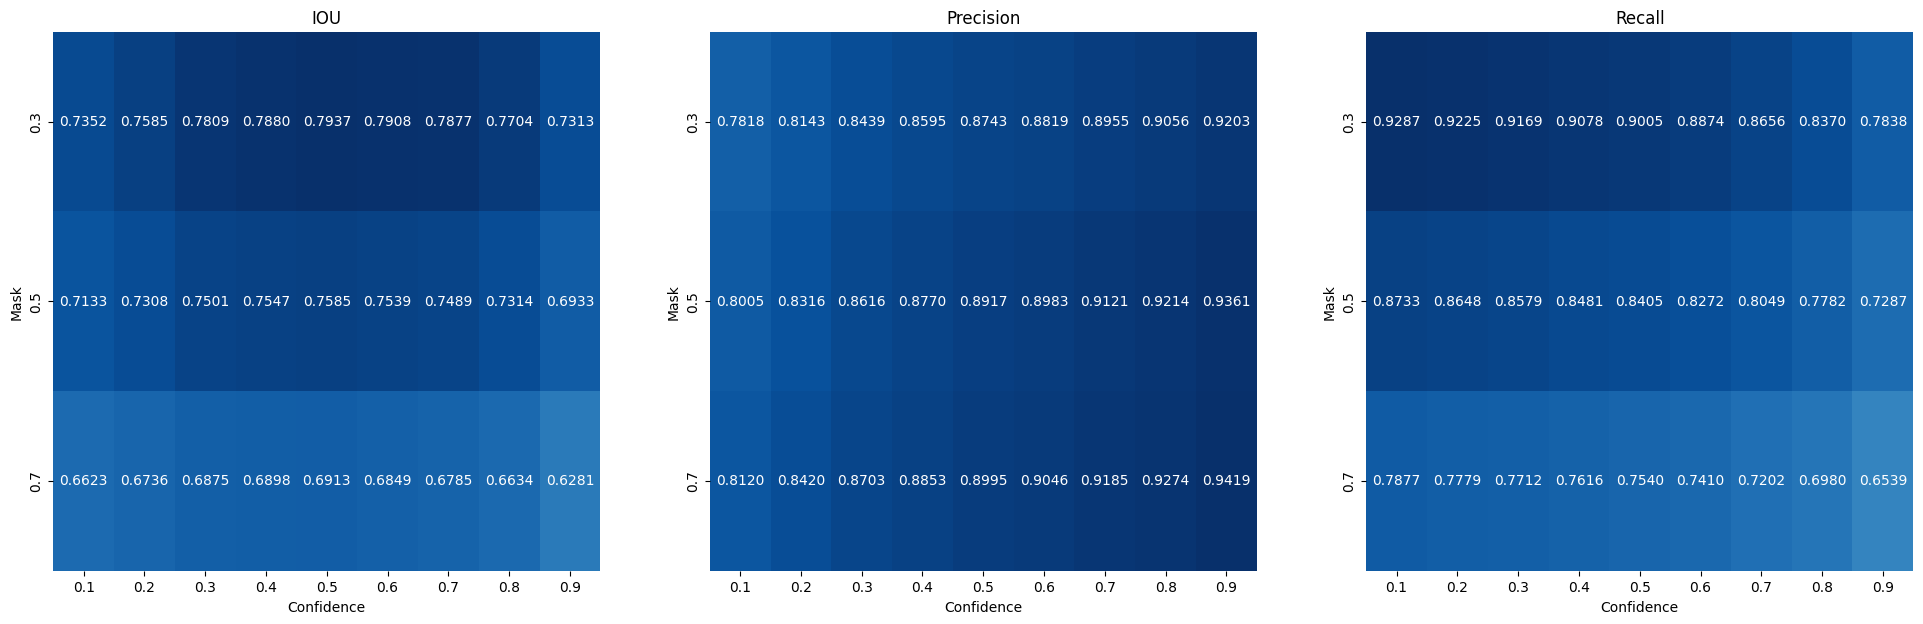

In [8]:
# исследование
mask_thresholds = [0.3, 0.5, 0.7]
confidence_thresholds = np.linspace(0.1, 0.9, 9)
fig, axes = plt.subplots(1, 3, figsize=(24,7))
iou_metric = []
prec_metric = []
rec_metric = []

for mask_th in mask_thresholds:
    for conf_th in confidence_thresholds:
        iou_score, *_, prec_score, rec_score = inference(model, ds, device=device, mask_threshold=mask_th, conf_threshold=conf_th, leave=False)
        iou_metric.append(iou_score)
        prec_metric.append(prec_score)
        rec_metric.append(rec_score)

def plot_mat(metric: list, name: str, ax) -> None:
    metric = np.array(metric).reshape(len(mask_thresholds), len(confidence_thresholds))
    xticklabels = [f"{x:.1f}" for x in confidence_thresholds]
    sns.heatmap(
        metric,
        ax=ax,
        yticklabels=mask_thresholds,
        xticklabels=xticklabels,
        cmap="Blues",
        center=0.5,
        annot=True,
        fmt=".4f",
        cbar=False,
    )
    ax.set_title(name)
    ax.set_xlabel("Confidence")
    ax.set_ylabel("Mask")

for i, (metric, name) in enumerate(zip((iou_metric, prec_metric, rec_metric), ("IOU", "Precision", "Recall"))):
    plot_mat(metric, name, axes[i])